In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
SEED = 42

# Generic Imports

In [3]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

In [4]:
from pathlib import Path
from enum import Enum
from typing import List, Tuple, Dict, Optional

# Loading the data
import tarfile
import urllib.request

# Data science
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

from pandas.plotting import scatter_matrix

In [5]:

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# Scikit-Learn Imports

In [6]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import uniform, loguniform

In [7]:
from scipy.stats import randint

In [8]:
sklearn.set_config(display="diagram")

# Utility functions

### Loading the data

In [ ]:
def load_data(file_name: str) -> pd.DataFrame:
    # data_root = "https://raw.githubusercontent.com/Ray-Man05/handson-mlp-main/refs/heads/main/Kaggle/Titanic - Machine Learning from Disaster"
    data_root = "https://raw.githubusercontent.com/Ray-Man05/handson-mlp-main/main/Kaggle/Titanic%20-%20Machine%20Learning%20from%20Disaster/"
    ext = ".csv"
    file_name = file_name + ext if not file_name.endswith(ext) else file_name
    
    try:
        df = pd.read_csv(data_root + file_name)
        return df
    except Exception as e:
        print(e)

def load_train_data() -> pd.DataFrame:
    train_file = "train.csv"
    try:
        load_data(train_file)
    except:
        print(f"Couldn't load data from GitHub, checking local folder for {train_file}.")

    try:
        return pd.read_csv(train_file)
    except:
        print(f"Couldn't load {train_file}, check your internet connexio or add it to the same folder as this notebook.")
    
class ColumnNamespace:
    """Simple namespace object for column names with autocomplete support"""
    def __init__(self, df):
        for col in df.columns:
            setattr(self, col, col)
    
    def __repr__(self):
        return f"Columns({', '.join(self.__dict__.keys())})"

In [20]:

# df_raw = load_train_data()
df_raw = pd.read_csv("train.csv")
df_full = df_raw.copy()
cols = ColumnNamespace(df_full)

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

### Plotting

In [ ]:
TARGET = 'Survived'

In [ ]:
def square_matrix_plots(attributes: List[str], df: pd.DataFrame = None, figsize: int = 20) -> None:
    
    if df is None:
        df = df_raw.copy()
        
    plt.figure(figsize=(figsize, figsize))
        
    # Calculate correlations
    corr_matrix = df[attributes].corr()

    # Create pairplot
    g = sns.pairplot(df[attributes], 
                        diag_kind='kde',
                        plot_kws={'alpha': 0.6, 's': 20},
                        height=2.5)

    # Add correlation coefficients to upper triangle
    for i, j in zip(*np.triu_indices_from(g.axes, 1)):
        corr = corr_matrix.iloc[i, j]
        g.axes[i, j].annotate(f'ρ={corr:.2f}', 
                                xy=(0.5, 0.9), 
                                xycoords='axes fraction',
                                ha='center', fontsize=9,
                                bbox=dict(boxstyle="round,pad=0.3", 
                                        facecolor="white", alpha=0.8))

    plt.suptitle(f'Pair Plot with Correlation Coefficients for:\n{attributes}', y=1.02)
    plt.tight_layout()
    plt.show()

def full_square_correlation_matrix(df: pd.DataFrame = None) -> None:

    if df is None:
        df = df_raw.copy()
        
    # Get only numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlation = df[numeric_cols].corr()

    # Create heatmap
    plt.figure(figsize=(24, 24))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', linewidths=1, 
                annot_kws={"size": 8}, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Numeric Features')
    plt.tight_layout()
    plt.show()
    
def scatter_plot_colormap(x: str = None, y: str = None, hue: str = '', 
                          xlabel: str = '', ylabel: str = '', cbar_title: str = 'Overall Quality', 
                          df: pd.DataFrame = None, 
                          palette: str = 'viridis', alpha: float = 0.6, plot_size: int = 10):
    
    if x is None or y is None:
        raise Exception("Must set x and y")
    
    if df is None:
        df = df_raw.copy()
        
    sns.set_style("whitegrid")

    plt.figure(figsize=(plot_size, plot_size))

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if hue:
        # Scatter plot with color 
        ax=sns.scatterplot(data=df, x=x, y=y, 
                            hue= hue, palette=palette, 
                            alpha=alpha, edgecolor='black', linewidth=0.1, legend=False)
        norm = plt.Normalize(df[hue].min(), df[hue].max())
        sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
        sm.set_array([])

        # Add colorbar
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label(cbar_title)
    else:
        ax=sns.scatterplot(data=df, x=x, y=y, alpha=alpha, edgecolor='black', linewidth=0.1, legend=False)


    plt.show()
    
    
def box_plot(attribute: str, target: str = TARGET, df: pd.DataFrame = None):

    if df is None:
        df = df_raw.copy()

    # Fill NaN with explicit string
    df[attribute] = df[attribute].fillna('Missing')

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=attribute, y=target)
    plt.xticks(rotation=45)
    plt.show()

        

### Dataframe Info

In [ ]:
class DataFrameInfo:
    """
    A utility class for analyzing DataFrame columns and their properties.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to analyze
    features_where_null_is_meaningful : list, optional
        List of column names where NaN represents meaningful absence (not an error)
    """
    
    def __init__(self, df: pd.DataFrame = None, target_col:str = TARGET, features_where_null_is_meaningful: List[str] = None):
        if df is None:
            self.df = df_raw.copy()
        else:
            self.df = df.copy()
        if target_col is not None and target_col in self.df.columns:
            self.df = self.df.drop(target_col, axis=1)
    
        self.meaningful_null_features = set(features_where_null_is_meaningful or [])
        self.info_df = self._build_info_dataframe()
    
    def _build_info_dataframe(self):
        """Construct the summary DataFrame with column metadata."""
        info_data = []
        
        for col in self.df.columns:
            feature_name = col
            data_type = str(self.df[col].dtype)
            contains_nan = self.df[col].isna().any()
            num_nan = self.df[col].isna().sum()
            nan_is_meaningful = col in self.meaningful_null_features
            
            info_data.append({
                'FeatureName': feature_name,
                'DataType': data_type,
                'ContainsNaN': contains_nan,
                'NaNisMeaningful': nan_is_meaningful,
                'NumberOfNaN': num_nan
            })
        
        return pd.DataFrame(info_data)
    
    def problematic_columns(self, with_counts: bool = False):
        """Return columns of any data type with NaN where NaN is NOT meaningful and that have at least one NaN value."""
        mask = self.info_df['ContainsNaN'] & ~self.info_df['NaNisMeaningful']
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def problematic_num_columns(self, with_counts: bool = False):
        """Return numeric columns with problematic NaN values. (NaN does NOT represent the absence of the feature)  and that have at least one NaN value"""
        prob_cols = set(self.problematic_columns())
        num_cols = set(self.num_columns())
        result_cols = list(prob_cols & num_cols)
        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]
        return result_cols
    
    def problematic_non_num_columns(self, with_counts: bool = False):
        """Return non-numeric columns with problematic NaN values. (NaN does NOT represent the absence of the feature)  and that have at least one NaN value """
        prob_cols = set(self.problematic_columns())
        non_num_cols = set(self.non_num_columns())
        result_cols = list(prob_cols & non_num_cols)
        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]
        return result_cols
    
    def num_columns(self, with_counts: bool = False):
        """Return all numeric column names."""
        numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
        mask = self.info_df['DataType'].isin(numeric_dtypes)
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def non_num_columns(self, with_counts: bool = False):
        """Return all non-numeric column names."""
        numeric_dtypes = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
        mask = ~self.info_df['DataType'].isin(numeric_dtypes)
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def columns_with_nan(self, with_counts: bool = False):
        """Return all columns containing NaN (regardless of whether it's meaningful or not)."""
        mask = self.info_df['ContainsNaN']
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def meaningful_nan_columns(self, with_counts: bool = False):
        """Return columns where NaN represents meaningful absence regardless of data type."""
        mask = self.info_df['ContainsNaN'] & self.info_df['NaNisMeaningful']
        cols = self.info_df.loc[mask, 'FeatureName'].tolist()
        if with_counts:
            counts = self.info_df.loc[mask, 'NumberOfNaN'].tolist()
            return list(zip(cols, counts))
        return cols
    
    def meaningful_nan_columns_non_num(self, with_counts: bool = False):
        """Return non-numeric columns where NaN is meaningful."""
        non_num = set(self.non_num_columns())
        meaningful = set(self.meaningful_nan_columns())
        result_cols = list(non_num & meaningful)

        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]

        return result_cols

    def non_meaningful_nan_columns_non_num(self, with_counts: bool = False):
        """Return non-numeric columns where NaN is NOT meaningful."""
        non_num = set(self.non_num_columns())
        meaningful = set(self.meaningful_nan_columns())
        result_cols = list(non_num - meaningful)

        if with_counts:
            counts_dict = dict(zip(self.info_df['FeatureName'], self.info_df['NumberOfNaN']))
            return [(col, counts_dict[col]) for col in result_cols]

        return result_cols
    
    def summary(self):
        """Print a summary of the DataFrame analysis."""
        print("=" * 60)
        print("DataFrame Info Summary")
        print("=" * 60)
        print(f"Total columns: {len(self.df.columns)}")
        print(f"Numeric columns: {len(self.num_columns())}")
        print(f"Non-numeric columns: {len(self.non_num_columns())}")
        print(f"Columns with NaN: {len(self.columns_with_nan())}")
        print(f"Columns with meaningful NaN: {len(self.meaningful_nan_columns())}")
        print(f"Problematic columns: {len(self.problematic_columns())}")
        print(f"  - Numeric: {len(self.problematic_num_columns())}")
        print(f"  - Non-numeric: {len(self.problematic_non_num_columns())}")
        print("=" * 60)
    
    def __repr__(self):
        return f"DataFrameInfo(columns={len(self.df.columns)}, problematic={len(self.problematic_columns())})"

In [ ]:
features_where_null_is_meaningful = []


df_info = DataFrameInfo(df_full, target_col=TARGET, features_where_null_is_meaningful=features_where_null_is_meaningful)

### Data preprocessing

In [ ]:
def remove_outliers(df: pd.DataFrame = None, column: str = TARGET, threshold: float = 1.5, verbose=True) -> pd.DataFrame:
    """
    Remove outliers from a dataframe based on a specific column.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe to filter
    column : str
        Column name to check for outliers
    threshold : float
        Multiplier for IQR 
    verbose : bool
        Print removal statistics
    
    Returns:
    --------
    pandas DataFrame with outliers removed
    """
    
    if df is None:
        df = df_raw.copy()
    
    original_count = len(df)

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    
    
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    
    df_filtered = df[
        (df[column] >= lower_bound) & 
        (df[column] <= upper_bound)
        ]
    
    if verbose:
        removed_count = original_count - len(df_filtered)
            
        print(f"{column} bounds: {lower_bound} - {upper_bound}")
        print(f"Removed {removed_count} outliers out of {original_count} datapoints in '{column}'")
    
    return df_filtered



In [ ]:
def remove_low_correlation_features(df: pd.DataFrame = None, target_col: str = TARGET, corr_threshold: float = 0.1, verbose: bool = True) -> pd.DataFrame:
    """
    Remove features with low correlation to the target variable.
    
    Parameters:
    -----------
    df : pandas DataFrame
        The dataframe containing features and target
    target_col : str
        Name of the target column
    threshold : float
        Minimum absolute correlation to keep feature 
    verbose : bool
        Print removal statistics
    
    Returns:
    --------
    pandas DataFrame with low-correlation features removed
    """
    
    if df is None:
        df = df_raw.copy()
    
    # Separate target
    y = df[target_col]
    X = df.drop(target_col, axis=1)
    
    # Get only numerical columns (can't correlate with categorical)
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
    
    # Calculate correlations
    correlations = X[numerical_cols].corrwith(y).abs()
    
    # Find features to keep
    features_to_keep = correlations[correlations >= corr_threshold].index.tolist()
    features_to_remove = correlations[correlations < corr_threshold].index.tolist()
    
    # Keep all categorical columns (they'll be handled by one-hot encoding)
    categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
    
    # Combine: keep high-correlation numerical + all categorical + target
    columns_to_keep = features_to_keep + categorical_cols + [target_col]
    df_filtered = df[columns_to_keep]
    
    if verbose:
        print(f"Correlation threshold: {corr_threshold}")
        print(f"Numerical features before: {len(numerical_cols)}")
        print(f"Numerical features after: {len(features_to_keep)}")
        print(f"Removed {len(features_to_remove)} low-correlation features:")
        print(f"  {features_to_remove}")
    
    return df_filtered

In [ ]:
def prepare_data(df: pd.DataFrame = None, target_col: str = TARGET, 
                 corr_threshold: float = 0.1, outliers_threshold: float = 1.5, 
                 outliers_feature: str = None,
                #  remove_inconsistent_rows: bool = False,
                 verbose: bool = True) -> pd.DataFrame:
    """
    Clean and prepare data. Run once on full dataset before splitting.
    
    Returns: df: A cleaned dataframe (outliers and low correlation features removed)
    """
    
    if df is None:
        df = df_raw.copy()
    
    
    # if remove_inconsistent_rows:
    #     print("Removing inconsistent rows:")
    #     df = remove_inconsistencies(df, verbose=verbose)
    
    if outliers_threshold > 0.0:
        print("Removing outliers:")
        df = remove_outliers(df, outliers_feature if outliers_feature is not None else target_col, outliers_threshold, verbose)
    
    if corr_threshold > 0.0:
        print(f"\nRemoving features with less than {corr_threshold} of correlation with {target_col}:")
        df = remove_low_correlation_features(df, target_col, corr_threshold, verbose)
    
    if verbose:
        print("\n")
        # Identify numerical and categorical columns
        numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        try: numerical_cols.remove(target_col) 
        except ValueError: pass
        categorical_cols = df.select_dtypes(include=['str', 'object']).columns.tolist()

        print(f"Numerical features: {len(numerical_cols)}")
        print(f"Categorical features: {len(categorical_cols)}")
    
    return df

### Pipelines

In [ ]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Add engineered features after initial transformations.
    Must receive a DataFrame with named columns.
    """
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.feature_names_out_ = None
    
    def fit(self, X, y=None):
        X_transformed = self.transform(X)
        self.feature_names_out_ = X_transformed.columns.tolist()
        return self
    
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)
        else:
            X = X.copy()

        # Name-based features
        if cols.Name in X.columns:
            name_series = X[cols.Name].astype(str)
            
            # Extract last name
            X["Last Name"] = name_series.str.extract(r"^\s*([^,]+),", expand=False)
            
            # Extract honorific (Mrs, Miss, Master, Mr)
            X["Honorific"] = name_series.str.extract(
                r",\s*(Mrs|Miss|Master|Mr)\s*\.",
                expand=False
            )
            
            # Drop original column
            X = X.drop(columns=[cols.Name])
        
        return X
    
    def get_feature_names_out(self, input_features=None):
        if self.feature_names_out_ is None:
            raise ValueError("Must call fit() before get_feature_names_out()")
        return np.array(self.feature_names_out_)

In [ ]:
def create_numeric_pipeline(log_features: List[str] = None):
    steps = []
    
    if log_features is not None and len(log_features) > 0:
        steps.append(("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")))
    
    steps.append(("scaler", StandardScaler()))
    
    return Pipeline(steps)
    

In [ ]:
def create_categorical_pipeline():
    cat_pipeline = Pipeline([
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return cat_pipeline

In [ ]:
features_where_null_is_meaningful = []

In [ ]:
LOG_COLS = [cols.Fare, cols.Age]

def create_preprocessor(X: pd.DataFrame, target_col: str = TARGET, dataframe_info: DataFrameInfo = None,
                        use_log_features: bool = True,
                        log_features: List[str] = [],
                        use_feature_engineering: bool = True,
                        ):
    
    if dataframe_info is None:
        dataframe_info = DataFrameInfo(X, target_col=target_col, features_where_null_is_meaningful=features_where_null_is_meaningful)   
        
    if use_feature_engineering:
        temp_fe = FeatureEngineer(feature_names=list(X.columns))
        X = temp_fe.fit_transform(X) 
    
    all_num = dataframe_info.num_columns()
    all_cat = dataframe_info.non_num_columns()
    num_cols = [col for col in all_num if col in X.columns]
    cat_cols = [col for col in all_cat if col in X.columns] 
    if log_features:
        log_cols = [col for col in num_cols if col in log_features]
        non_log_cols = [col for col in num_cols if col not in log_features]
    else:
        log_cols = []
        non_log_cols = num_cols
    
    
    transformers  = []
    if log_cols:
        transformers.append(("num_log", create_numeric_pipeline(log_features=log_cols), log_cols))
    if non_log_cols:
        transformers.append(("num", create_numeric_pipeline(log_features=None), non_log_cols))
    if cat_cols:
        transformers.append(("cat", create_categorical_pipeline(), cat_cols))
    
    column_transformer = ColumnTransformer(transformers, sparse_threshold=0)
    
    pipeline_steps = []
    if use_feature_engineering:
        pipeline_steps.append(
            ('feature_engineer', FeatureEngineer(feature_names=list(X.columns)))
        )
    
    pipeline_steps.extend([
        ('transformer', column_transformer),
        ("knnimputer", KNNImputer(n_neighbors=5, weights="distance"))
    ])
    
    pipeline = Pipeline(pipeline_steps)
    
    return pipeline

### Training

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import inspect

def unwrap_estimator(model):
    """
    Returns (final_estimator, cv_wrapper or None)
    """
    cv_wrapper = None

    if isinstance(model, (GridSearchCV, RandomizedSearchCV)):
        cv_wrapper = model
        model = model.best_estimator_

    if isinstance(model, Pipeline):
        final_estimator = model.steps[-1][1]
    else:
        final_estimator = model

    return final_estimator, cv_wrapper


def non_default_params(estimator):
    """
    Return parameters whose values differ from constructor defaults.
    """
    sig = inspect.signature(estimator.__class__)
    defaults = {
        k: v.default
        for k, v in sig.parameters.items()
        if v.default is not inspect.Parameter.empty
    }

    current = estimator.get_params(deep=False)

    return {
        k: v
        for k, v in current.items()
        if k in defaults and v != defaults[k]
    }


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss
)
import numpy as np


def train_and_evaluate_classifier(model, X_train, X_test, y_train, y_test, technique_name="Model", verbose: bool = True):
    model.fit(X_train, y_train)

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Probabilities (if supported)
    supports_proba = hasattr(model, "predict_proba")
    if supports_proba:
        y_proba_train = model.predict_proba(X_train)[:, 1]
        y_proba_test = model.predict_proba(X_test)[:, 1]

    # --- Metrics ---
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    auc_train = auc_test = None
    logloss_train = logloss_test = None

    if supports_proba:
        auc_train = roc_auc_score(y_train, y_proba_train)
        auc_test = roc_auc_score(y_test, y_proba_test)

        logloss_train = log_loss(y_train, y_proba_train)
        logloss_test = log_loss(y_test, y_proba_test)

    final_estimator, cv = unwrap_estimator(model)

    # --- Gender-only baseline ---
    gender_col = cols.Sex

    # Estimate P(y=1 | gender) on training set
    gender_probs = (
        pd.DataFrame({"Sex": X_train[gender_col], "y": y_train})
        .groupby("Sex")["y"]
        .mean()
    )

    # Predict on test set
    baseline_pred = X_test[gender_col].map(
        lambda g: int(gender_probs.get(g, y_train.mean()) >= 0.5)
    )

    baseline_acc = accuracy_score(y_test, baseline_pred)


    if verbose:
        print(f"\nTraining {technique_name}")
        print("\n" + "=" * 60)
        print(f"{technique_name.upper()} RESULTS")
        print("=" * 60)

        # --- CV info ---
        if cv is not None:
            print("Cross-validation:")
            print(f"  CV type:     {cv.__class__.__name__}")
            print(f"  Scoring:     {cv.scoring}")
            print(f"  Best score:  {cv.best_score_:.4f}")
            print(f"  Best params: {cv.best_params_}")
            print()

        # --- Metrics ---
        print("Performance:")
        print(f"  Train accuracy: {acc_train:.4f}")
        print(f"  Test accuracy:  {acc_test:.4f}")
        print(f"  Accuracy gap:   {acc_train - acc_test:.4f}")

        if supports_proba:
            print(f"\n  Train ROC AUC:  {auc_train:.4f}")
            print(f"  Test ROC AUC:   {auc_test:.4f}")
            print(f"  AUC gap:        {auc_train - auc_test:.4f}")

            print(f"\n  Train log loss: {logloss_train:.4f}")
            print(f"  Test log loss:  {logloss_test:.4f}")

        print("\nBaseline (majority class):")
        print(f"  Baseline accuracy: {baseline_acc:.4f}")
        print(f"  Accuracy gain:     {acc_test - baseline_acc:.4f}")

        print("=" * 60)

        # --- Estimator info ---
        print("Estimator:")
        print(f"  Class: {final_estimator.__class__.__name__}")

        params = non_default_params(final_estimator)
        if params:
            print("  Non-default hyperparameters:")
            for k, v in params.items():
                print(f"    {k}: {v}")
        else:
            print("  All hyperparameters at default values")

    # --- Results dict ---
    result = {
        "Model": technique_name,
        "Train Accuracy": acc_train,
        "Test Accuracy": acc_test,
        "Accuracy Gap": acc_train - acc_test,
        "Baseline Accuracy": baseline_acc,
        "Accuracy Gain": acc_test - baseline_acc,
        "Train ROC AUC": auc_train,
        "Test ROC AUC": auc_test,
        "Train Log Loss": logloss_train,
        "Test Log Loss": logloss_test,
        "CV Score": None,
        "Best Params": None,
    }

    # --- CV handling ---
    if hasattr(model, "best_score_"):
        result["CV Score"] = model.best_score_
        result["Best Params"] = model.best_params_

    return model, result


# Exploring the data

In [13]:
df = df_full
df_full

NameError: name 'df_full' is not defined

In [ ]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
df_info.columns_with_nan()

['Age', 'Cabin', 'Embarked']

In [ ]:
df[
    df[cols.Embarked].notna()
]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Plots

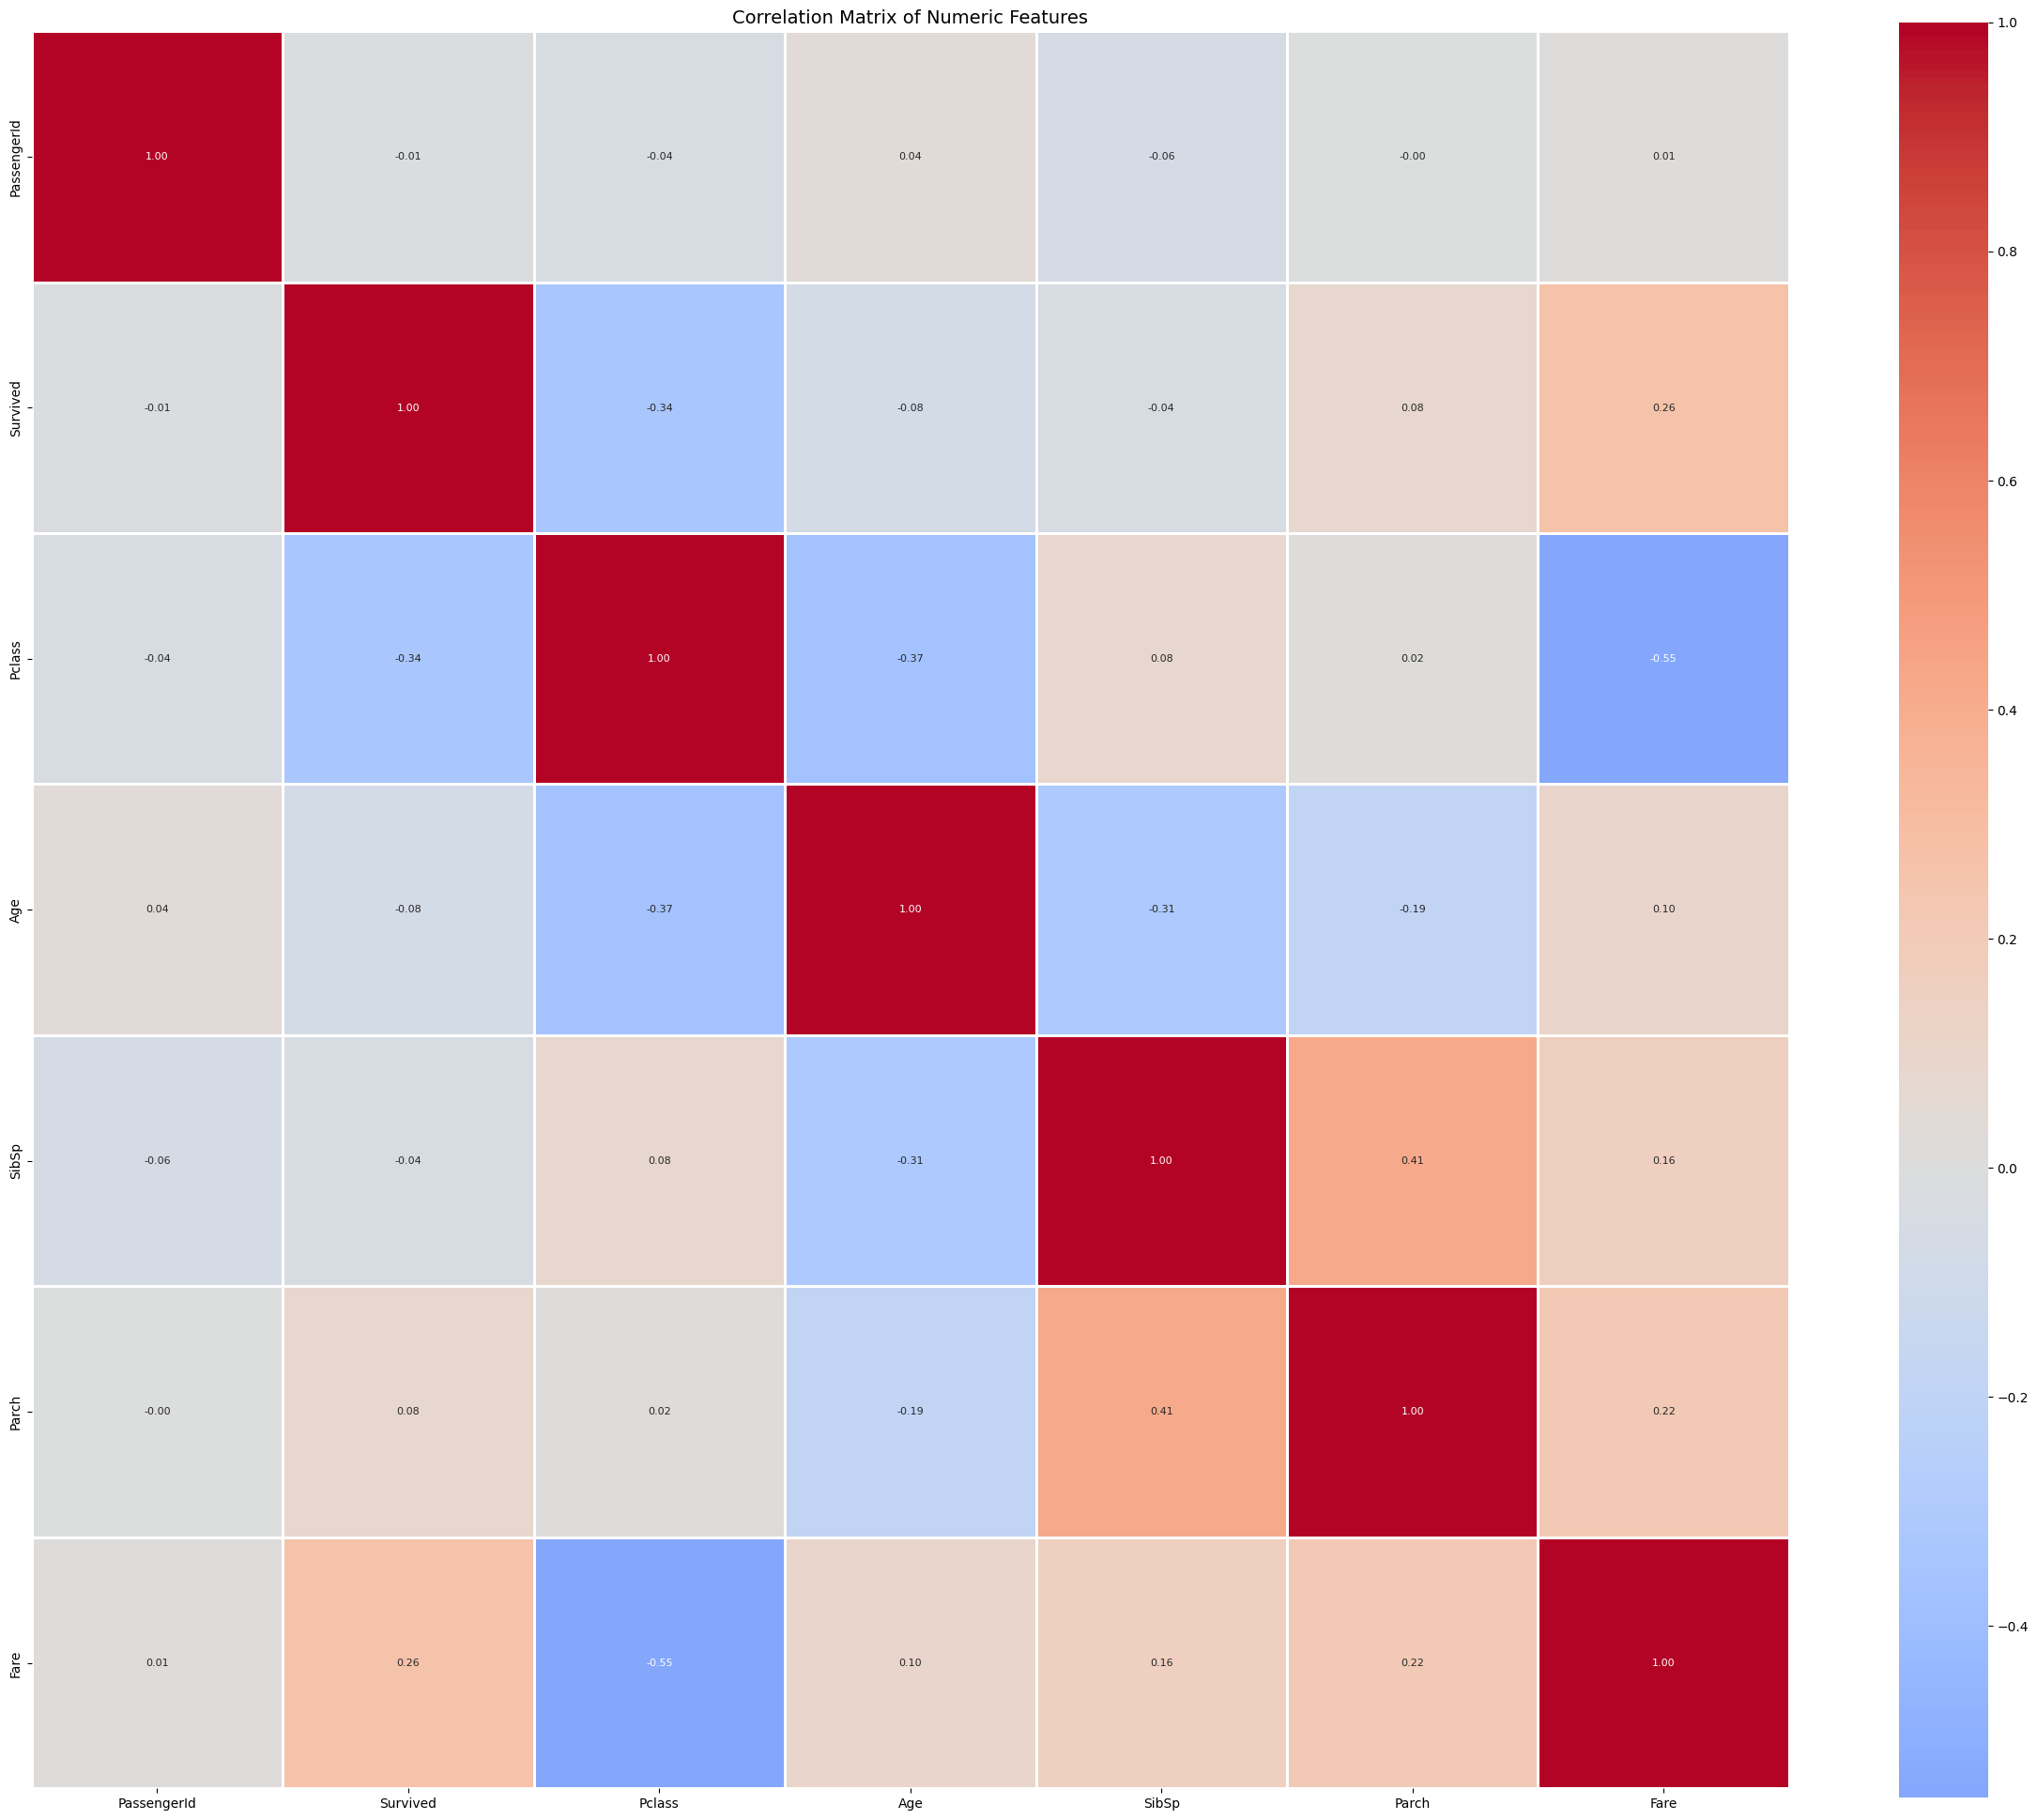

In [34]:
full_square_correlation_matrix(df)

<Figure size 2000x2000 with 0 Axes>

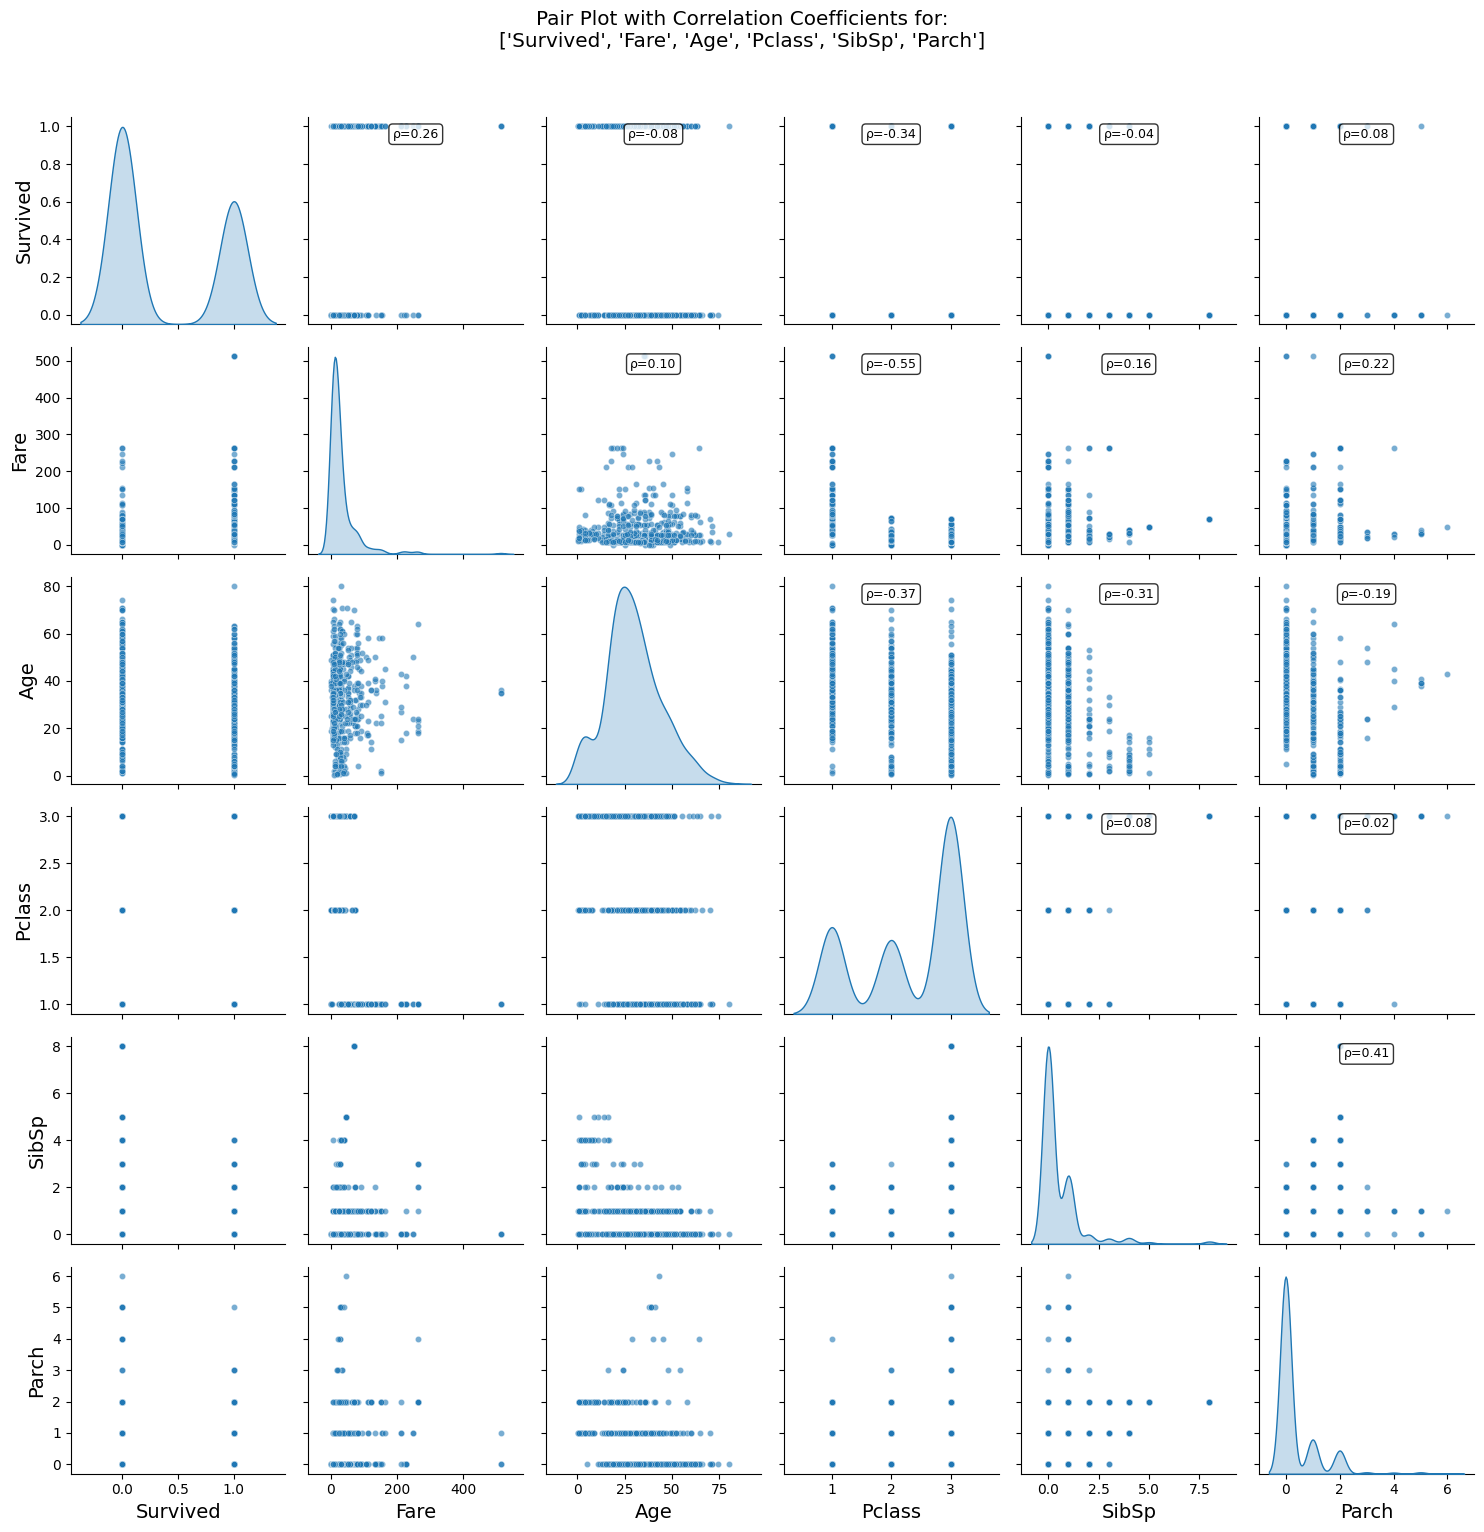

In [60]:
attributes = [cols.Survived, cols.Fare, cols.Age, cols.Pclass, cols.SibSp, cols.Parch]

# scatter_matrix(df[attributes], figsize=(15, 15), grid=True)
square_matrix_plots(attributes)

<Figure size 2000x2000 with 0 Axes>

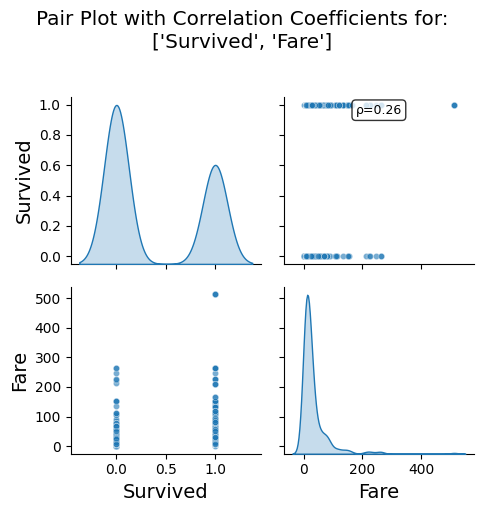

In [44]:
square_matrix_plots([cols.Survived, cols.Fare])

# Preparing the data

In [14]:
df_full = df_raw.copy()

df_full = prepare_data(df, cols.Survived, outliers_threshold=0.0, corr_threshold=0.0)

AttributeError: 'NoneType' object has no attribute 'copy'

In [ ]:
df_full

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
X = df_full.drop(TARGET, axis=1)

# X = X.drop(cols.PassengerId, axis=1)
y = df_full[TARGET]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED
                                                    stratify=df_full["Sex"]
                                                    )

In [ ]:
print("Columns in X_train:", X_train.columns.tolist())
print("Does Name exist?", cols.Name in X_train.columns)

Columns in X_train: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Does Name exist? True


In [ ]:
preprocessor = create_preprocessor(
    X_train, TARGET, df_info,
    use_log_features=True
)

# Training the models

In [119]:
def what_was_before(res):
    try:
        old= res.copy()
        print(f"""What you just had:\n{old["Model"]}:
            Test Accuracy: {old["Test Accuracy"]}
            Test ROC AUC: {old["Test ROC AUC"]}
            Test Log Loss: {old["Test Log Loss"]}""")
    except:
        pass

### RandomForest

In [143]:
rf_preprocessor = create_preprocessor(
    X_train, TARGET, df_info,
    use_log_features=True,
    
)

In [144]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

rf_pipeline = Pipeline([
    ("preprocess", rf_preprocessor),
    ("clf", RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1
    ))
])

param_distributions = {
    "clf__n_estimators": randint(200, 1000),
    "clf__max_depth": [None, 5, 10, 20, 40, 60, 80, 120],
    "clf__min_samples_split": randint(2, 20),
    "clf__min_samples_leaf": randint(1, 10),
    "clf__max_features": ["sqrt", "log2", None],
}


rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)


In [145]:
try:
    old= rf_res.copy()
    print(f"""What you just had:\n{old["Model"]}:
          Test Accuracy: {old["Test Accuracy"]}
          Test ROC AUC: {old["Test ROC AUC"]}
          Test Log Loss: {old["Test Log Loss"]}""")
except:
    pass

rf_model, rf_res = train_and_evaluate_classifier(rf_search, X_train, X_test, y_train, y_test, technique_name="Random Forest")

What you just had:
Random Forest:
          Test Accuracy: 0.8324022346368715
          Test ROC AUC: 0.8961389961389961
          Test Log Loss: 1.2696862679324101
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Training Random Forest

RANDOM FOREST RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     roc_auc
  Best score:  0.8642
  Best params: {'clf__max_depth': 40, 'clf__max_features': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 8, 'clf__n_estimators': 720}

Performance:
  Train accuracy: 0.9930
  Test accuracy:  0.8324
  Accuracy gap:   0.1606

  Train ROC AUC:  0.9993
  Test ROC AUC:   0.8961
  AUC gap:        0.1031

  Train log loss: 0.1019
  Test log loss:  1.2697

Baseline (majority class):
  Baseline accuracy: 0.7821
  Accuracy gain:     0.0503
Estimator:
  Class: RandomForestClassifier
  Non-default hyperparameters:
    max_depth: 40
    max_features: None
    min_samples_split: 8
    n_estimators: 720
    n_jobs: -1
    

In [147]:
best_rf = rf_model.best_estimator_

### XGBoost 

In [ ]:
xgb_preprocessor = create_preprocessor(
    X_train, TARGET, df_info,
    use_log_features=True,
    use_feature_engineering=True,
)

In [133]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_pipeline = Pipeline([
    ("preprocess", xgb_preprocessor),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1
    ))
])

param_distributions = {
    "clf__n_estimators": randint(200, 1000),
    "clf__max_depth": randint(1, 12),
    "clf__learning_rate": uniform(0.01, 0.29),  
    "clf__subsample": uniform(0.2, 0.8),        
    "clf__colsample_bytree": uniform(0.2, 0.8), 
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": uniform(0.0, 10.0),
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=80,
    scoring="roc_auc",
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)


In [134]:
try: what_was_before(xgb_res)
except: pass
xgb_model, xgb_res = train_and_evaluate_classifier(xgb_search, X_train, X_test, y_train, y_test, technique_name="XGBClassifier")

What you just had:
XGBClassifier:
            Test Accuracy: 0.8100558659217877
            Test ROC AUC: 0.8778635778635778
            Test Log Loss: 0.4399889452345258
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Training XGBClassifier

XGBCLASSIFIER RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     roc_auc
  Best score:  0.8575
  Best params: {'clf__colsample_bytree': np.float64(0.804440910834439), 'clf__gamma': np.float64(2.2879816549162246), 'clf__learning_rate': np.float64(0.03232417385034997), 'clf__max_depth': 11, 'clf__min_child_weight': 3, 'clf__n_estimators': 285, 'clf__subsample': np.float64(0.9043742712122063)}

Performance:
  Train accuracy: 0.8652
  Test accuracy:  0.8101
  Accuracy gap:   0.0551

  Train ROC AUC:  0.9237
  Test ROC AUC:   0.9028
  AUC gap:        0.0210

  Train log loss: 0.3499
  Test log loss:  0.4166

Baseline (majority class):
  Baseline accuracy: 0.7821
  Accuracy gain:     0.0279
Estimator:
  Class: XGBC

In [135]:
best_xgb = xgb_model.best_estimator_

### SVM

In [169]:
svm_preprocessor = create_preprocessor(
    X_train, TARGET, df_info,
    use_log_features=False,
    use_feature_engineering=True,
)

In [170]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

svm_pipeline = Pipeline([
    ("preprocess", svm_preprocessor),
    ("clf", SVC(
        probability=True,  # Required for roc_auc scoring
        random_state=SEED,
        cache_size=1000,  # Increase cache for faster training
    ))
])

param_distributions = {
    "clf__C": loguniform(1e-2, 1e3),           # Regularization parameter
    "clf__gamma": loguniform(1e-4, 1e1),       # Kernel coefficient for 'rbf'
    "clf__kernel": ['rbf', 'linear', 'poly'],  # Kernel type
    "clf__degree": [2, 3, 4],                  # Only for poly kernel
    "clf__class_weight": [None, 'balanced'],   # Handle class imbalance
}

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_distributions,
    n_iter=80,
    scoring="roc_auc",
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)



In [171]:
try: 
    what_was_before(svm_res)
except: 
    pass
svm_model, svm_res = train_and_evaluate_classifier(
    svm_search, X_train, X_test, y_train, y_test, 
    technique_name="SVC"
)

What you just had:
SVC:
            Test Accuracy: 0.8379888268156425
            Test ROC AUC: 0.9226512226512228
            Test Log Loss: 0.3558590063558205
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Training SVC

SVC RESULTS
Cross-validation:
  CV type:     RandomizedSearchCV
  Scoring:     roc_auc
  Best score:  0.8698
  Best params: {'clf__C': np.float64(252.54524452421066), 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': np.float64(0.0030072423528674903), 'clf__kernel': 'rbf'}

Performance:
  Train accuracy: 0.9874
  Test accuracy:  0.8436
  Accuracy gap:   0.1438

  Train ROC AUC:  0.9976
  Test ROC AUC:   0.9247
  AUC gap:        0.0729

  Train log loss: 0.1203
  Test log loss:  0.3566

Baseline (majority class):
  Baseline accuracy: 0.7821
  Accuracy gain:     0.0615
Estimator:
  Class: SVC
  Non-default hyperparameters:
    C: 252.54524452421066
    cache_size: 1000
    class_weight: balanced
    degree: 2
    gamma: 0.00300724235286749

In [172]:
best_svm = svm_model.best_estimator_

# Making predictions

In [189]:
test_data=pd.read_csv('test.csv')
test_data = prepare_data(test_data, cols.Survived, outliers_threshold=0.0, corr_threshold=0.0)

test_ids = test_data['PassengerId'].copy()


X_submission = test_data.copy()


X_submission = X_submission[X_train.columns]




Numerical features: 6
Categorical features: 5


In [174]:
# X_full = X.copy()
# y_full = y.copy()

# best_rf.fit(X_full, y_full)
# best_xgb.fit(X_full, y_full)

In [190]:
rf_pred = best_rf.predict(X_submission)
xgb_pred = best_xgb.predict(X_submission)
svm_pred = best_svm.predict(X_submission)

In [191]:
rf_x = rf_res["Test Accuracy"]
xgb_x = xgb_res["Test Accuracy"]
svm_x = svm_res["Test Accuracy"]

total = rf_x+xgb_x+svm_x
xgb_coeff = xgb_x/total
rf_coeff = rf_x/total
svm_coeff = svm_x/total

In [ ]:
ensemble_predictions = (
???
) 

submission = pd.DataFrame({
    cols.PassengerId: test_ids,
    TARGET: ensemble_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\nSubmission file created with {len(submission)} predictions")


Submission file created with 891 predictions


In [192]:
# Get probability predictions from each model (NOT hard predictions)
# Assuming your models are stored as rf_model, xgb_model, svm_model
rf_proba = rf_model.predict_proba(X_submission)[:, 1]   # Probability of class 1
xgb_proba = xgb_model.predict_proba(X_submission)[:, 1]
svm_proba = svm_model.predict_proba(X_submission)[:, 1]

# Weight by test ROC AUC (better metric than accuracy for probabilities)
rf_auc = rf_res["Test ROC AUC"]
xgb_auc = xgb_res["Test ROC AUC"]
svm_auc = svm_res["Test ROC AUC"]

total = rf_auc + xgb_auc + svm_auc
rf_coeff = rf_auc / total
xgb_coeff = xgb_auc / total
svm_coeff = svm_auc / total

# Weighted ensemble of probabilities
ensemble_proba = (
    rf_coeff * rf_proba +
    xgb_coeff * xgb_proba +
    svm_coeff * svm_proba
)

# Convert probabilities to hard predictions (0.5 threshold)
ensemble_predictions = (ensemble_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    cols.PassengerId: test_ids,
    TARGET: ensemble_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\nSubmission file created with {len(submission)} predictions")
print(f"Ensemble weights: RF={rf_coeff:.3f}, XGB={xgb_coeff:.3f}, SVM={svm_coeff:.3f}")
print(f"Class distribution: {submission[TARGET].value_counts().to_dict()}")


Submission file created with 418 predictions
Ensemble weights: RF=0.329, XGB=0.331, SVM=0.340
Class distribution: {0: 283, 1: 135}
